# Causal localization

## Setup and model

Load Qwen3-0.6B for residual-stream patching.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from transformer_lens import HookedTransformer

MODEL_NAME = "Qwen/Qwen3-0.6B"
model = HookedTransformer.from_pretrained(MODEL_NAME)
model.eval()

print(f"Model: {MODEL_NAME}")
print(f"Layers: {model.cfg.n_layers}")
print(f"Residual width: {model.cfg.d_model}")

## Clean and corrupted baseline

Create token-aligned prompts and measure the Alice-Bob logit difference at the answer position.


In [3]:
clean_user_prompt = """Answer the question with exactly one name.

Alice is older than Bob.
Bob is older than Charlie.

Who is the oldest?"""

corrupt_user_prompt = clean_user_prompt.replace("older than Bob", "younger than Bob", 1)

def make_readout_text(user_prompt):
    messages = [{"role": "user", "content": user_prompt}]
    chat_prefix = model.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )
    return chat_prefix + "Answer:"

clean_text = make_readout_text(clean_user_prompt)
corrupt_text = make_readout_text(corrupt_user_prompt)

clean_tokens = model.to_tokens(clean_text, prepend_bos=False)
corrupt_tokens = model.to_tokens(corrupt_text, prepend_bos=False)

assert clean_tokens.shape == corrupt_tokens.shape, (
    f"Prompt token shapes differ: {clean_tokens.shape} vs {corrupt_tokens.shape}"
)
different_positions = (clean_tokens[0] != corrupt_tokens[0]).nonzero(as_tuple=False).flatten().tolist()
assert len(different_positions) == 1, (
    f"Expected exactly one differing token, found positions {different_positions}."
)
relation_pos = different_positions[0]
clean_relation_token = model.to_string(clean_tokens[0, relation_pos])
corrupt_relation_token = model.to_string(corrupt_tokens[0, relation_pos])
assert clean_relation_token.strip() == "older", repr(clean_relation_token)
assert corrupt_relation_token.strip() == "younger", repr(corrupt_relation_token)
assert torch.equal(clean_tokens[0, :relation_pos], corrupt_tokens[0, :relation_pos])
assert torch.equal(clean_tokens[0, relation_pos + 1:], corrupt_tokens[0, relation_pos + 1:])

print(clean_text)
print(f"Token count: {clean_tokens.shape[1]}")
print(f"Changed relation position: {relation_pos}")
print(f"Clean token: {clean_relation_token!r}")
print(f"Corrupted token: {corrupt_relation_token!r}")

<|im_start|>user
Answer the question with exactly one name.

Alice is older than Bob.
Bob is older than Charlie.

Who is the oldest?<|im_end|>
<|im_start|>assistant
<think>

</think>

Answer:
Token count: 39
Changed relation position: 13
Clean token: ' older'
Corrupted token: ' younger'


Positive values favor Alice.


In [4]:
alice_token = model.to_single_token(" Alice")
bob_token = model.to_single_token(" Bob")
assert model.to_string(alice_token) == " Alice"
assert model.to_string(bob_token) == " Bob"

def answer_logit_gap(logits):
    final_logits = logits[0, -1]
    return (final_logits[alice_token] - final_logits[bob_token]).item()

with torch.inference_mode():
    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    corrupt_logits, corrupt_cache = model.run_with_cache(corrupt_tokens)

D_clean = answer_logit_gap(clean_logits)
D_corr = answer_logit_gap(corrupt_logits)
recovery_denominator = D_clean - D_corr
assert abs(recovery_denominator) > 1e-6, (
    "Normalized recovery is undefined because clean and corrupted logit gaps are equal."
)

print(f"Alice token id: {alice_token}")
print(f"Bob token id: {bob_token}")
print(f"D_clean = {D_clean:.6f}")
print(f"D_corr  = {D_corr:.6f}")
print(f"D_clean - D_corr = {recovery_denominator:.6f}")

Alice token id: 29405
Bob token id: 14261
D_clean = 2.095922
D_corr  = -3.164007
D_clean - D_corr = 5.259930


## Relation-token layer scan

Patch the clean state at the changed relation token into the corrupted run, one layer at a time.


In [5]:
def run_single_position_patch(base_tokens, source_cache, hook_name, position):
    source_vector = source_cache[hook_name][0, position].detach().clone()

    def patch_residual(activation, hook):
        patched = activation.clone()
        patched[0, position] = source_vector
        return patched

    return model.run_with_hooks(
        base_tokens,
        fwd_hooks=[(hook_name, patch_residual)],
    )

rows = []
with torch.inference_mode():
    for layer in range(model.cfg.n_layers):
        hook_name = f"blocks.{layer}.hook_resid_post"

        patched_logits = run_single_position_patch(
            corrupt_tokens, clean_cache, hook_name, relation_pos
        )
        clean_identity_logits = run_single_position_patch(
            clean_tokens, clean_cache, hook_name, relation_pos
        )
        corrupt_identity_logits = run_single_position_patch(
            corrupt_tokens, corrupt_cache, hook_name, relation_pos
        )

        D_patched = answer_logit_gap(patched_logits)
        DeltaD = D_patched - D_corr
        R = DeltaD / recovery_denominator
        D_clean_identity = answer_logit_gap(clean_identity_logits)
        D_corr_identity = answer_logit_gap(corrupt_identity_logits)

        rows.append({
            "layer": layer,
            "D_patched": D_patched,
            "DeltaD": DeltaD,
            "R": R,
            "clean_to_clean_DeltaD": D_clean_identity - D_clean,
            "corrupt_to_corrupt_DeltaD": D_corr_identity - D_corr,
        })

results = pd.DataFrame(rows)
pd.set_option("display.max_rows", model.cfg.n_layers)
print(results.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

identity_atol = 1e-6
identity_rtol = 5e-5
identity_scale = max(abs(D_clean), abs(D_corr), 1.0)
identity_tolerance = identity_atol + identity_rtol * identity_scale
max_clean_identity_error = results["clean_to_clean_DeltaD"].abs().max()
max_corr_identity_error = results["corrupt_to_corrupt_DeltaD"].abs().max()
print(f"\nMax |clean→clean DeltaD|: {max_clean_identity_error:.3e}")
print(f"Max |corrupted→corrupted DeltaD|: {max_corr_identity_error:.3e}")
print(f"Identity tolerance (atol + rtol × scale): {identity_tolerance:.3e}")
assert max_clean_identity_error < identity_tolerance
assert max_corr_identity_error < identity_tolerance

 layer  D_patched    DeltaD         R  clean_to_clean_DeltaD  corrupt_to_corrupt_DeltaD
     0  -0.210817  2.953190  0.561450               0.000000                   0.000000
     1  -0.596714  2.567293  0.488085               0.000000                   0.000000
     2  -1.256582  1.907425  0.362633               0.000000                   0.000000
     3  -1.670458  1.493549  0.283949               0.000000                   0.000000
     4  -2.135433  1.028574  0.195549               0.000000                   0.000000
     5  -2.134893  1.029114  0.195652               0.000000                   0.000000
     6  -2.531700  0.632307  0.120212               0.000000                   0.000000
     7  -2.676044  0.487963  0.092770               0.000000                   0.000000
     8  -2.713404  0.450603  0.085667               0.000000                   0.000000
     9  -2.741276  0.422731  0.080368               0.000000                   0.000000
    10  -2.772793  0.391214  0.0

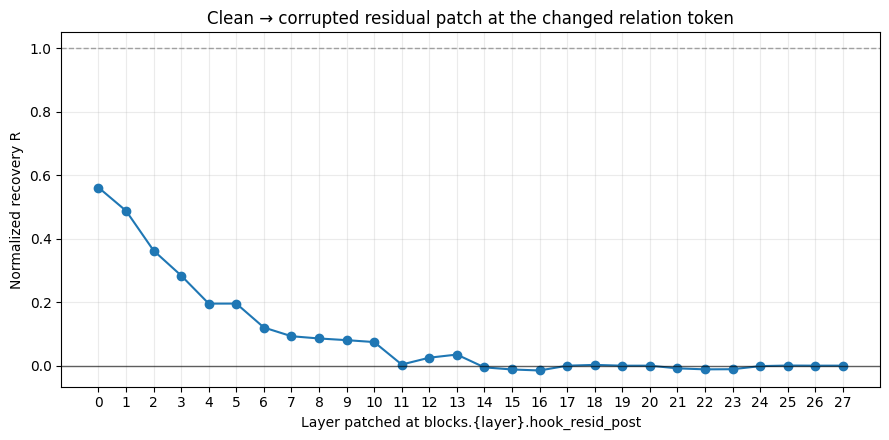

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(results["layer"], results["R"], marker="o", linewidth=1.5)
ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
ax.axhline(1.0, color="gray", linewidth=1, linestyle="--", alpha=0.7)
ax.set_xticks(range(model.cfg.n_layers))
ax.set_xlabel("Patched layer")
ax.set_ylabel("Normalized recovery R")
ax.set_title("Clean → corrupted residual patch at the changed relation token")
ax.grid(alpha=0.25)
fig.tight_layout()

from pathlib import Path
figure_dir = Path.cwd().parent / "figures" if Path.cwd().name == "notebooks" else Path.cwd() / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "phase-a-relation-token-layer-scan.png", dpi=250, bbox_inches="tight")
plt.show()

Positive recovery localizes causal availability, not where the information was first computed.


## Position x layer scan

Patch one prompt-token residual vector at a time across all layers.


In [7]:
n_positions = clean_tokens.shape[1]
positions = torch.arange(n_positions, device=clean_tokens.device)
batch_indices = torch.arange(n_positions, device=clean_tokens.device)

clean_token_text = model.to_str_tokens(clean_tokens[0])
corrupt_token_text = model.to_str_tokens(corrupt_tokens[0])
token_labels = []
for position, (clean_token, corrupt_token) in enumerate(
    zip(clean_token_text, corrupt_token_text)
):
    shown_token = (
        f"{clean_token.strip()}/{corrupt_token.strip()}"
        if position == relation_pos
        else clean_token.replace("\n", "\\n")
    )
    token_labels.append(f"{position}:{shown_token}")

def run_all_single_position_patches(base_tokens, source_cache, hook_name):
    # Batch row p is an independent run patched only at prompt position p.
    batched_tokens = base_tokens.repeat(n_positions, 1)
    source_vectors = source_cache[hook_name][0, :n_positions].detach().clone()

    def patch_residual(activation, hook):
        patched = activation.clone()
        patched[batch_indices, positions] = source_vectors
        return patched

    return model.run_with_hooks(
        batched_tokens,
        fwd_hooks=[(hook_name, patch_residual)],
    )

def batched_answer_logit_gaps(logits):
    final_logits = logits[:, -1]
    return final_logits[:, alice_token] - final_logits[:, bob_token]

grid_rows = []
with torch.inference_mode():
    for layer in range(model.cfg.n_layers):
        hook_name = f"blocks.{layer}.hook_resid_post"
        patched_logits = run_all_single_position_patches(
            corrupt_tokens, clean_cache, hook_name
        )
        clean_identity_logits = run_all_single_position_patches(
            clean_tokens, clean_cache, hook_name
        )
        corrupt_identity_logits = run_all_single_position_patches(
            corrupt_tokens, corrupt_cache, hook_name
        )

        D_patched_by_position = batched_answer_logit_gaps(patched_logits)
        D_clean_identity_by_position = batched_answer_logit_gaps(clean_identity_logits)
        D_corr_identity_by_position = batched_answer_logit_gaps(corrupt_identity_logits)

        for position in range(n_positions):
            D_patched = D_patched_by_position[position].item()
            DeltaD = D_patched - D_corr
            grid_rows.append({
                "layer": layer,
                "position": position,
                "clean_token": clean_token_text[position],
                "corrupt_token": corrupt_token_text[position],
                "D_patched": D_patched,
                "DeltaD": DeltaD,
                "R": DeltaD / recovery_denominator,
                "clean_to_clean_DeltaD": (
                    D_clean_identity_by_position[position].item() - D_clean
                ),
                "corrupt_to_corrupt_DeltaD": (
                    D_corr_identity_by_position[position].item() - D_corr
                ),
            })

grid_results = pd.DataFrame(grid_rows)
assert len(grid_results) == model.cfg.n_layers * n_positions
print(
    f"Completed {len(grid_results)} clean→corrupted single-activation patches "
    f"({model.cfg.n_layers} layers × {n_positions} prompt positions)."
)

Completed 1092 clean→corrupted single-activation patches (28 layers × 39 prompt positions).


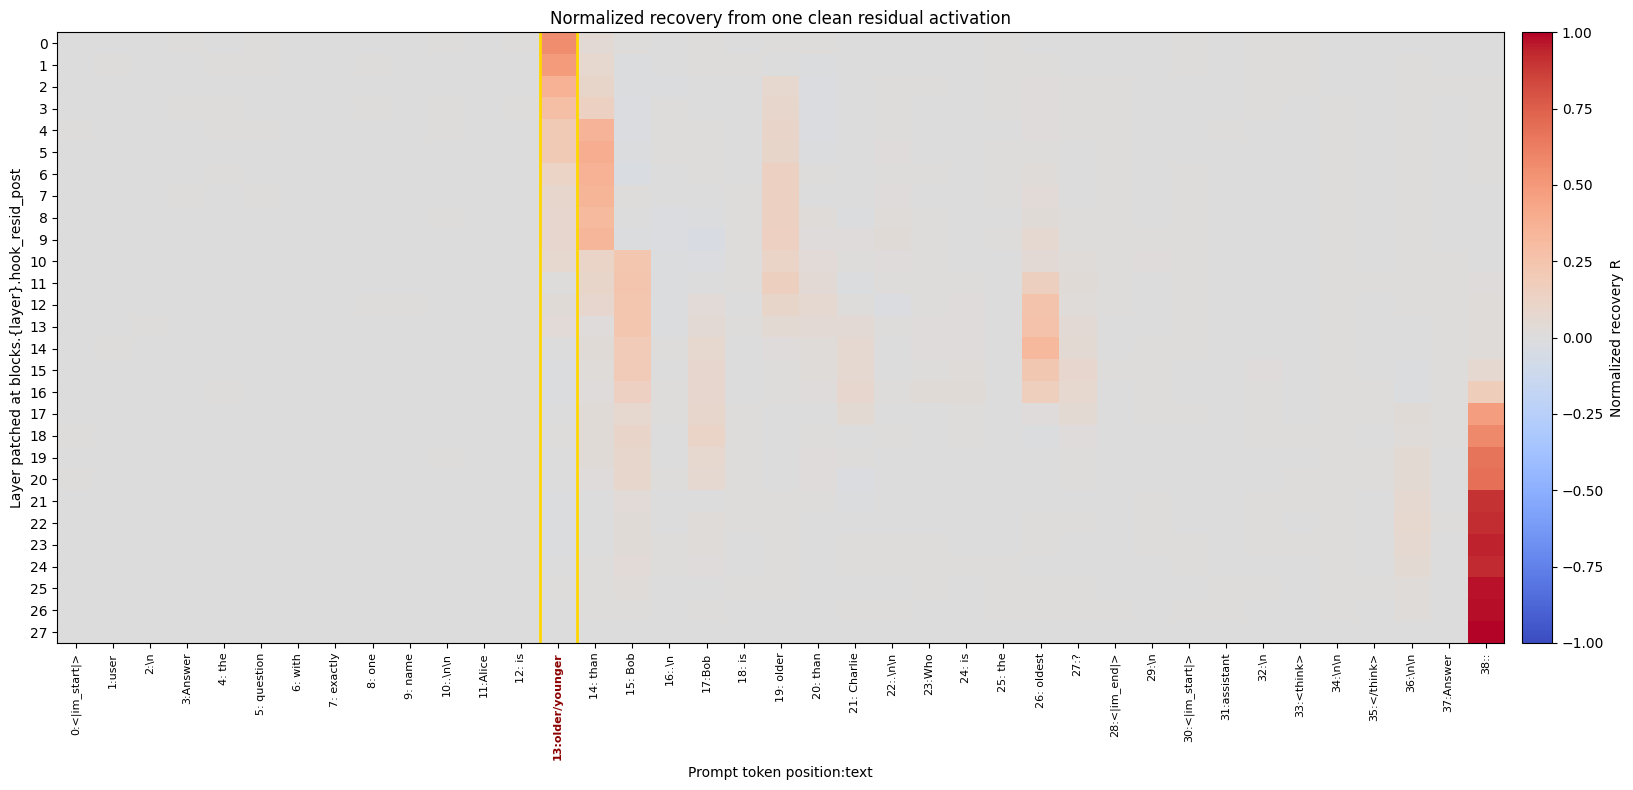

In [8]:
recovery_grid = (
    grid_results.pivot(index="layer", columns="position", values="R")
    .sort_index()
    .sort_index(axis=1)
)

fig, ax = plt.subplots(figsize=(18, 8))
max_abs_recovery = max(abs(recovery_grid.to_numpy()).max(), 1e-12)
image = ax.imshow(
    recovery_grid.to_numpy(),
    aspect="auto",
    origin="upper",
    cmap="coolwarm",
    vmin=-max_abs_recovery,
    vmax=max_abs_recovery,
)
ax.set_xticks(range(n_positions))
ax.set_xticklabels(token_labels, rotation=90, fontsize=8)
ax.set_yticks(range(model.cfg.n_layers))
ax.set_yticklabels(range(model.cfg.n_layers))
ax.set_xlabel("Prompt token position:text")
ax.set_ylabel("Patched layer")
ax.set_title("Normalized recovery from one clean residual activation")

# Mark the changed older/younger position on both the heatmap and tick label.
ax.axvline(relation_pos - 0.5, color="gold", linewidth=2)
ax.axvline(relation_pos + 0.5, color="gold", linewidth=2)
changed_tick = ax.get_xticklabels()[relation_pos]
changed_tick.set_color("darkred")
changed_tick.set_fontweight("bold")
colorbar = fig.colorbar(image, ax=ax, pad=0.01)
colorbar.set_label("Normalized recovery R")
fig.tight_layout()

from pathlib import Path
figure_dir = Path.cwd().parent / "figures" if Path.cwd().name == "notebooks" else Path.cwd() / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "phase-a-position-layer-heatmap.png", dpi=250, bbox_inches="tight")
plt.show()

In [9]:
report_columns = [
    "layer", "position", "clean_token", "corrupt_token",
    "D_patched", "DeltaD", "R",
]
top_10_by_DeltaD = grid_results.nlargest(10, "DeltaD")[report_columns]
top_10_by_R = grid_results.nlargest(10, "R")[report_columns]

print("Top 10 patches by raw DeltaD:")
print(top_10_by_DeltaD.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\nTop 10 patches by normalized recovery R:")
print(top_10_by_R.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

Top 10 patches by raw DeltaD:
 layer  position clean_token corrupt_token  D_patched   DeltaD        R
    27        38           :             :   2.095922 5.259930 1.000000
    26        38           :             :   2.004616 5.168623 0.982641
    25        38           :             :   1.934982 5.098989 0.969403
    23        38           :             :   1.799282 4.963289 0.943604
    24        38           :             :   1.701160 4.865168 0.924949
    22        38           :             :   1.677572 4.841579 0.920465
    21        38           :             :   1.578804 4.742811 0.901687
    20        38           :             :   0.433413 3.597420 0.683929
    19        38           :             :   0.351103 3.515110 0.668281
    18        38           :             :  -0.148380 3.015627 0.573321

Top 10 patches by normalized recovery R:
 layer  position clean_token corrupt_token  D_patched   DeltaD        R
    27        38           :             :   2.095922 5.259930 1

In [10]:
grid_max_clean_identity_error = grid_results["clean_to_clean_DeltaD"].abs().max()
grid_max_corr_identity_error = grid_results["corrupt_to_corrupt_DeltaD"].abs().max()

print("Identity controls over the complete layer × prompt-position grid:")
print(f"Max |clean→clean DeltaD|: {grid_max_clean_identity_error:.3e}")
print(f"Max |corrupted→corrupted DeltaD|: {grid_max_corr_identity_error:.3e}")
print(f"Relative to baseline scale: {max(grid_max_clean_identity_error, grid_max_corr_identity_error) / identity_scale:.3e}")
print(f"Allowed (atol + rtol × scale): {identity_tolerance:.3e}")
assert grid_max_clean_identity_error < identity_tolerance
assert grid_max_corr_identity_error < identity_tolerance

Identity controls over the complete layer × prompt-position grid:
Max |clean→clean DeltaD|: 5.531e-05
Max |corrupted→corrupted DeltaD|: 5.531e-05


## Identity controls

Same-condition patches should have numerically zero effect.


## Name-permutation generalization

Repeat the relation-token scan across qualified single-token name permutations.


In [11]:
import itertools
import random

# Relative numerical tolerance shared by the identity-control summaries.
identity_atol, identity_rtol = 1e-6, 5e-5

candidate_names = ["Alice", "Bob", "Charlie", "David", "Emma", "Frank",
                   "Grace", "Henry", "Irene", "Jack", "Kate", "Liam"]
target_examples, minimum_examples = 12, 10
candidate_triples = list(itertools.permutations(candidate_names, 3))
random.Random(0).shuffle(candidate_triples)

def permutation_prompts(A, B, C):
    clean = f"""Answer the question with exactly one name.

{A} is older than {B}.
{B} is older than {C}.

Who is the oldest?"""
    corrupt = clean.replace("is older than", "is younger than", 1)
    return make_readout_text(clean), make_readout_text(corrupt)

qualified_examples, rejected_examples = [], []
with torch.inference_mode():
    for A, B, C in candidate_triples:
        if len(qualified_examples) >= target_examples:
            break
        reason = None
        try:
            A_token, B_token = model.to_single_token(f" {A}"), model.to_single_token(f" {B}")
        except AssertionError:
            reason = "answer name is not a single token"
        if reason is None:
            clean_text_i, corrupt_text_i = permutation_prompts(A, B, C)
            clean_i = model.to_tokens(clean_text_i, prepend_bos=False)
            corrupt_i = model.to_tokens(corrupt_text_i, prepend_bos=False)
            differing = ((clean_i[0] != corrupt_i[0]).nonzero(as_tuple=False).flatten().tolist()
                         if clean_i.shape == corrupt_i.shape else [])
            if len(differing) != 1:
                reason = f"prompt alignment failed: {differing}"
            else:
                relation_i = differing[0]
                pair = (model.to_string(clean_i[0, relation_i]).strip(),
                        model.to_string(corrupt_i[0, relation_i]).strip())
                if pair != ("older", "younger"):
                    reason = f"changed tokens are {pair}"
        if reason is None:
            resid_post_only = lambda name: name.endswith("hook_resid_post")
            clean_logits_i, clean_cache_i = model.run_with_cache(clean_i, names_filter=resid_post_only)
            corrupt_logits_i, corrupt_cache_i = model.run_with_cache(corrupt_i, names_filter=resid_post_only)
            D_clean_i = (clean_logits_i[0, -1, A_token] - clean_logits_i[0, -1, B_token]).item()
            D_corr_i = (corrupt_logits_i[0, -1, A_token] - corrupt_logits_i[0, -1, B_token]).item()
            if not (D_clean_i > 0 and D_corr_i < 0):
                reason = f"behavioral gap failed: D_clean={D_clean_i:.4f}, D_corr={D_corr_i:.4f}"
        if reason is not None:
            rejected_examples.append({"A": A, "B": B, "C": C, "reason": reason})
            continue
        qualified_examples.append({"example": len(qualified_examples), "A": A, "B": B, "C": C,
            "A_token": A_token, "B_token": B_token, "clean_tokens": clean_i, "corrupt_tokens": corrupt_i,
            "relation_pos": relation_i, "D_clean": D_clean_i, "D_corr": D_corr_i,
            "clean_cache": clean_cache_i, "corrupt_cache": corrupt_cache_i})

assert len(qualified_examples) >= minimum_examples
baseline_table = pd.DataFrame([{k: e[k] for k in ["example", "A", "B", "C", "relation_pos", "D_clean", "D_corr"]}
                               for e in qualified_examples])
print(f"Qualified: {len(qualified_examples)}; rejected before target: {len(rejected_examples)}")
print(baseline_table.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
if rejected_examples:
    print("\nRejected candidates:")
    print(pd.DataFrame(rejected_examples).to_string(index=False))

Qualified: 12; rejected before target: 9
 example     A       B     C  relation_pos  D_clean    D_corr
       0   Bob Charlie Alice            13 0.152191 -5.037546
       1  Emma   David Grace            13 0.692247 -5.326693
       2 David Charlie Alice            13 1.384632 -5.054068
       3 Irene   Alice  Emma            14 0.583553 -6.620838
       4  Jack   Henry David            13 0.819311 -4.594406
       5 Henry Charlie  Liam            13 2.598497 -3.627327
       6  Liam   David Irene            14 1.597191 -3.520628
       7 Frank    Emma Alice            13 0.899597 -5.698677
       8  Emma   Alice Irene            13 0.180841 -5.247503
       9  Liam    Jack David            14 3.842077 -2.374851
      10   Bob   Henry Grace            13 0.112751 -7.372343
      11  Liam   Frank Irene            14 0.582125 -4.874846

Rejected candidates:
      A     B       C                                                  reason
   Kate Alice   David  behavioral gap failed: D_clean

In [12]:
generalization_rows = []
with torch.inference_mode():
    for e in qualified_examples:
        denominator = e["D_clean"] - e["D_corr"]
        for layer in range(model.cfg.n_layers):
            hook_name = f"blocks.{layer}.hook_resid_post"
            patched = run_single_position_patch(e["corrupt_tokens"], e["clean_cache"], hook_name, e["relation_pos"])
            clean_identity = run_single_position_patch(e["clean_tokens"], e["clean_cache"], hook_name, e["relation_pos"])
            corr_identity = run_single_position_patch(e["corrupt_tokens"], e["corrupt_cache"], hook_name, e["relation_pos"])
            def gap(logits):
                return (logits[0, -1, e["A_token"]] - logits[0, -1, e["B_token"]]).item()
            D_patched_i = gap(patched)
            generalization_rows.append({"example": e["example"], "A": e["A"], "B": e["B"], "C": e["C"],
                "layer": layer, "D_patched": D_patched_i, "DeltaD": D_patched_i - e["D_corr"],
                "R": (D_patched_i - e["D_corr"]) / denominator,
                "clean_to_clean_DeltaD": gap(clean_identity) - e["D_clean"],
                "corrupt_to_corrupt_DeltaD": gap(corr_identity) - e["D_corr"]})
generalization_results = pd.DataFrame(generalization_rows)
assert len(generalization_results) == len(qualified_examples) * model.cfg.n_layers
print(f"Completed {len(generalization_results)} reduced relation-position patches.")

Completed 336 reduced relation-position patches.


In [13]:
layer_summary = generalization_results.groupby("layer").agg(mean_R=("R", "mean"), std_R=("R", "std")).reset_index()
early_layers = list(range(6))
early_results = generalization_results[generalization_results["layer"].isin(early_layers)]
early_fraction_by_layer = early_results.groupby("layer")["DeltaD"].apply(lambda x: (x > 0).mean()).rename("fraction_DeltaD_positive").reset_index()
fraction_examples_early_clean_direction = (early_results.groupby("example")["DeltaD"].mean() > 0).mean()
max_recovery_layers = generalization_results.loc[generalization_results.groupby("example")["R"].idxmax(),
    ["example", "A", "B", "C", "layer", "R"]].sort_values("example")
mean_layer_of_max_recovery = max_recovery_layers["layer"].mean()

print("Mean and standard deviation of R by layer:")
print(layer_summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))
print("\nFraction with DeltaD > 0 at each early layer (0–5):")
print(early_fraction_by_layer.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"\nFraction whose mean layer-0–5 effect is clean-directed: {fraction_examples_early_clean_direction:.3f}")
print(f"Mean layer of maximum recovery: {mean_layer_of_max_recovery:.3f}")
print("\nPer-example maxima:")
print(max_recovery_layers.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

Mean and standard deviation of R by layer:
 layer    mean_R    std_R
     0  0.542572 0.203479
     1  0.436602 0.143004
     2  0.353377 0.115445
     3  0.262130 0.087095
     4  0.181267 0.062901
     5  0.198190 0.063144
     6  0.127382 0.045211
     7  0.118417 0.042571
     8  0.114500 0.038316
     9  0.103013 0.031800
    10  0.095255 0.026872
    11  0.027144 0.015099
    12  0.032655 0.020406
    13  0.045572 0.019538
    14  0.006612 0.021342
    15 -0.010627 0.019007
    16 -0.005478 0.018200
    17 -0.001370 0.013734
    18  0.002671 0.013210
    19 -0.000393 0.013485
    20 -0.003549 0.012553
    21 -0.005601 0.010892
    22 -0.001664 0.008851
    23 -0.000361 0.008136
    24 -0.003115 0.008163
    25 -0.000050 0.003333
    26  0.000022 0.000085
    27  0.000000 0.000000

Fraction with DeltaD > 0 at each early layer (0–5):
 layer  fraction_DeltaD_positive
     0                     1.000
     1                     1.000
     2                     1.000
     3            

In [14]:
gen_clean_error = generalization_results["clean_to_clean_DeltaD"].abs().max()
gen_corr_error = generalization_results["corrupt_to_corrupt_DeltaD"].abs().max()
gen_scale = max(baseline_table["D_clean"].abs().max(), baseline_table["D_corr"].abs().max(), 1.0)
gen_tolerance = identity_atol + identity_rtol * gen_scale
gen_error = max(gen_clean_error, gen_corr_error)
print("Generalization identity controls:")
print(f"Max |clean→clean DeltaD|: {gen_clean_error:.3e}")
print(f"Max |corrupted→corrupted DeltaD|: {gen_corr_error:.3e}")
print(f"Observed error relative to baseline scale: {gen_error / gen_scale:.3e}")
print(f"Allowed (atol + rtol × scale): {gen_tolerance:.3e}")
assert gen_error <= gen_tolerance

Generalization identity controls:
Max |clean→clean DeltaD|: 0.000e+00
Max |corrupted→corrupted DeltaD|: 0.000e+00
Observed error relative to baseline scale: 0.000e+00
Allowed (atol + rtol × scale): 3.696e-04


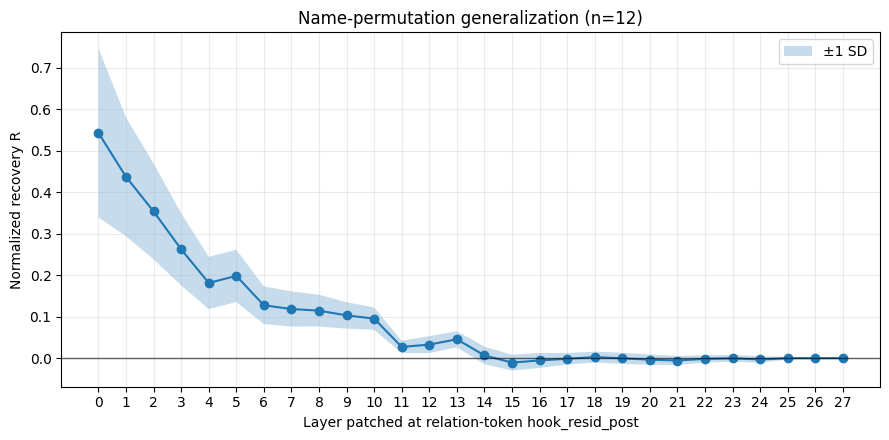

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(layer_summary["layer"], layer_summary["mean_R"], marker="o")
ax.fill_between(layer_summary["layer"], layer_summary["mean_R"] - layer_summary["std_R"],
                layer_summary["mean_R"] + layer_summary["std_R"], alpha=0.25, label="±1 SD")
ax.axhline(0, color="black", linewidth=1, alpha=0.6)
ax.set_xticks(range(model.cfg.n_layers))
ax.set_xlabel("Patched layer")
ax.set_ylabel("Normalized recovery R")
ax.set_title(f"Name-permutation generalization "
             f"({len(qualified_examples)} / "
             f"{len(qualified_examples) + len(rejected_examples)} qualified)")
ax.legend(); ax.grid(alpha=0.25); fig.tight_layout(); 
from pathlib import Path
figure_dir = Path.cwd().parent / "figures" if Path.cwd().name == "notebooks" else Path.cwd() / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "phase-a-name-generalization.png", dpi=250, bbox_inches="tight")
plt.show()

Positive recovery across names does not distinguish abstract from lexical representations.


## Conclusion

Of **21 permutations**, **12 qualified** and **9 failed the clean baseline**. Mean recovery was $0.543 \pm 0.203$ at layer 0, $0.437 \pm 0.143$ at layer 1, $0.353 \pm 0.115$ at layer 2, $0.262 \pm 0.087$ at layer 3, and about $0.18$–$0.20$ at layers 4–5 before declining toward zero.

All qualified examples had $\Delta D>0$ at layers 0–5; 11 peaked at layer 0 and one at layer 1. Generalization is conditional on correct baselines and does not establish robust performance across arbitrary name assignments.